In [6]:
import os
from glob import glob
data_dir = "/mnt/oracle_data/killeen/NMDID-ARCADE/diffusion_vertebrae_data/case_100012/torso"
sorted(glob(os.path.join(data_dir, "*.nii.gz")))

['/mnt/oracle_data/killeen/NMDID-ARCADE/diffusion_vertebrae_data/case_100012/torso/case-100012_26_cropped_vertebra.nii.gz',
 '/mnt/oracle_data/killeen/NMDID-ARCADE/diffusion_vertebrae_data/case_100012/torso/case-100012_27_cropped_vertebra.nii.gz',
 '/mnt/oracle_data/killeen/NMDID-ARCADE/diffusion_vertebrae_data/case_100012/torso/case-100012_28_cropped_vertebra.nii.gz',
 '/mnt/oracle_data/killeen/NMDID-ARCADE/diffusion_vertebrae_data/case_100012/torso/case-100012_29_cropped_vertebra.nii.gz',
 '/mnt/oracle_data/killeen/NMDID-ARCADE/diffusion_vertebrae_data/case_100012/torso/case-100012_30_cropped_vertebra.nii.gz',
 '/mnt/oracle_data/killeen/NMDID-ARCADE/diffusion_vertebrae_data/case_100012/torso/case-100012_31_cropped_vertebra.nii.gz',
 '/mnt/oracle_data/killeen/NMDID-ARCADE/diffusion_vertebrae_data/case_100012/torso/case-100012_32_cropped_vertebra.nii.gz',
 '/mnt/oracle_data/killeen/NMDID-ARCADE/diffusion_vertebrae_data/case_100012/torso/case-100012_33_cropped_vertebra.nii.gz',
 '/mnt/o

In [30]:
import nibabel as nib
import numpy as np
import os 

nifti_file_path = "/mnt/oracle_data/killeen/NMDID-ARCADE/diffusion_vertebrae_data/case-191176/TORSO/case-191176_26_cropped_vertebra.nii.gz"
nifti_img = nib.load(nifti_file_path)
origin = nifti_img.affine[:3, 3]  
spacing = nifti_img.header.get_zooms()[:3]  
print("Origin (in mm):", origin)
print("Spacing (in mm):", spacing)

Origin (in mm): [ 129.0625  -246.90625 -636.     ]
Spacing (in mm): (0.7421875, 0.7421875, 0.5)


In [ ]:
nifti_img.affine

array([[-7.4218750e-01,  0.0000000e+00, -0.0000000e+00,  1.2906250e+02],
       [-0.0000000e+00,  7.4218750e-01, -0.0000000e+00, -2.4690625e+02],
       [ 0.0000000e+00,  0.0000000e+00,  5.0000000e-01, -6.3600000e+02],
       [ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  1.0000000e+00]])

In [31]:
import killeengeo as kg 

In [35]:
volume = nifti_img.get_fdata()

In [37]:
volume.shape

(73, 69, 84)

In [81]:
import torch
import torch.nn.functional as F

def rotate_volume_uniformly_torch(volume_tensor, max_angle=np.pi):
    """
    Rotate a 3D volume uniformly using PyTorch.
    
    Parameters:
        volume_tensor: 3D tensor of shape [1, 1, D, H, W] (batch, channel, depth, height, width)
        max_angle: maximum rotation angle in radians
        
    Returns:
        Rotated 3D volume
    """
    # Get rotation vector and matrix as before
    max_angle = np.random.uniform(0, max_angle)
    rotation_vector = kg.random.spherical_uniform(center=kg.vector(0, 0, 1), d_phi=max_angle, n=None)
    rotation_matrix = kg.vector([0, 0, 1]).rotfrom(rotation_vector)
    #print(np.array(rotation_matrix))
    # Convert to PyTorch tensor and reshape for affine_grid
    
    theta = torch.tensor(np.array(rotation_matrix), dtype=torch.float32)
    theta = theta[:3, :]
    # We need to convert the 3x3 rotation matrix to a 3x4 affine matrix
    # The last column is zero (no translation)
    print(theta)
    #theta = torch.cat([theta, torch.zeros(3, 1)], dim=1)
    
    # Make sure volume is in correct format [B, C, D, H, W]
    if len(volume_tensor.shape) == 3:
        volume_tensor = volume_tensor.unsqueeze(0).unsqueeze(0)
    
    # Create sampling grid
    grid = F.affine_grid(
        theta.unsqueeze(0),  # Add batch dimension
        volume_tensor.size(),
        align_corners=True
    )
    
    # Sample the volume at the grid locations
    rotated_volume = F.grid_sample(
        volume_tensor,
        grid,
        mode='bilinear',  # Or 'nearest', 'bicubic'
        padding_mode='zeros',  # Or 'border', 'reflection'
        align_corners=True
    )
    
    return rotated_volume.squeeze()  # Remove batch and channel dims

0.8850402823017859

In [88]:
vol = rotate_volume_uniformly_torch(volume_tensor=torch.tensor(volume, dtype=torch.float32))
import nibabel as nib
import torch

# Assume 'vol' is a PyTorch tensor
vol_numpy = vol.cpu().numpy()  # Move to CPU and convert to NumPy array

# original_affine from your loaded NIfTI image
original_affine = nifti_img.affine

# Save the rotated image with nibabel
rotated_img = nib.Nifti1Image(vol_numpy, original_affine)
nib.save(rotated_img, 'rotated_volume.nii.gz')


tensor([[ 0.9865, -0.0483, -0.1563,  0.0000],
        [-0.0483,  0.8267, -0.5605,  0.0000],
        [ 0.1563,  0.5605,  0.8133,  0.0000]])


In [56]:
volume.shape

(73, 69, 84)

In [55]:
vol.shape

torch.Size([73, 69, 84])

Volume shape: torch.Size([73, 69, 84])


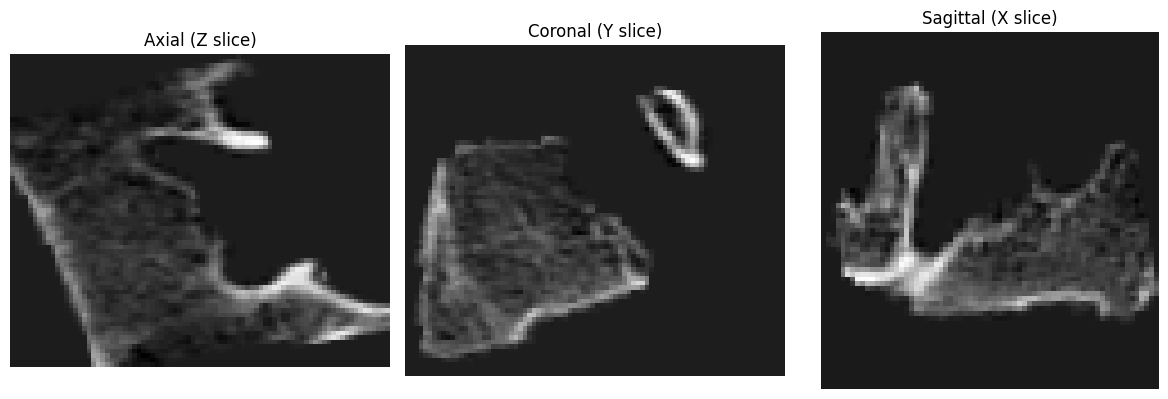

In [57]:
import numpy as np
import matplotlib.pyplot as plt

def plot_volume_slices(vol):
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))

    mid_z, mid_y, mid_x = np.array(vol.shape) // 2

    axes[0].imshow(vol[mid_z, :, :], cmap='gray')
    axes[0].set_title('Axial (Z slice)')
    
    axes[1].imshow(vol[:, mid_y, :], cmap='gray')
    axes[1].set_title('Coronal (Y slice)')
    
    axes[2].imshow(vol[:, :, mid_x], cmap='gray')
    axes[2].set_title('Sagittal (X slice)')

    for ax in axes:
        ax.axis('off')

    plt.tight_layout()
    plt.show()

# Example usage:
print("Volume shape:", vol.shape)
plot_volume_slices(vol)


Volume shape: torch.Size([73, 69, 84])


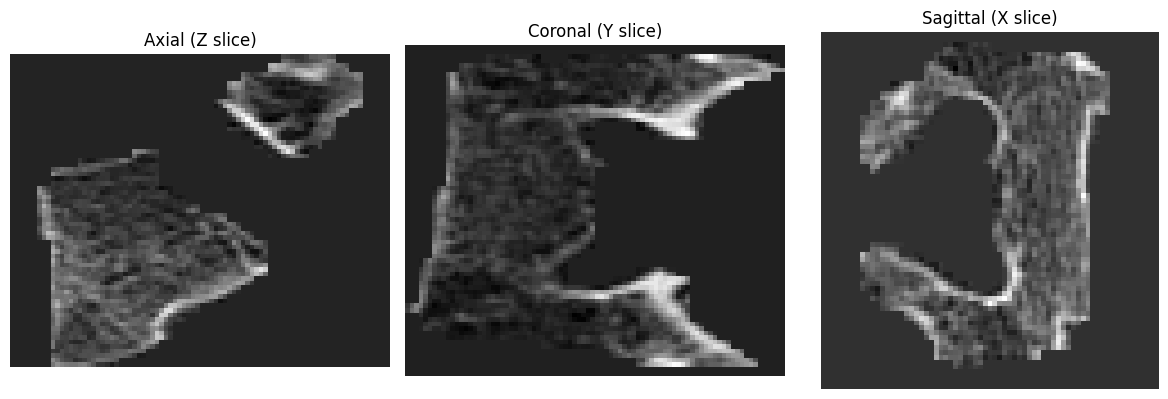

In [58]:
import numpy as np
import matplotlib.pyplot as plt

def plot_volume_slices(vol):
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))

    mid_z, mid_y, mid_x = np.array(vol.shape) // 2

    axes[0].imshow(vol[mid_z, :, :], cmap='gray')
    axes[0].set_title('Axial (Z slice)')
    
    axes[1].imshow(vol[:, mid_y, :], cmap='gray')
    axes[1].set_title('Coronal (Y slice)')
    
    axes[2].imshow(vol[:, :, mid_x], cmap='gray')
    axes[2].set_title('Sagittal (X slice)')

    for ax in axes:
        ax.axis('off')

    plt.tight_layout()
    plt.show()

# Example usage:
print("Volume shape:", vol.shape)
plot_volume_slices(volume)


In [66]:
import nibabel as nib
import torch

# Assume 'vol' is a PyTorch tensor
vol_numpy = vol.cpu().numpy()  # Move to CPU and convert to NumPy array

# original_affine from your loaded NIfTI image
original_affine = nifti_img.affine

# Save the rotated image with nibabel
rotated_img = nib.Nifti1Image(vol_numpy, original_affine)
nib.save(rotated_img, 'rotated_volume.nii.gz')
